# TD et sa correction

In [1]:
import matplotlib.pyplot as plt
import scipy.signal as si
import numpy as np
plt.style.use('../../src/signal.mplstyle')

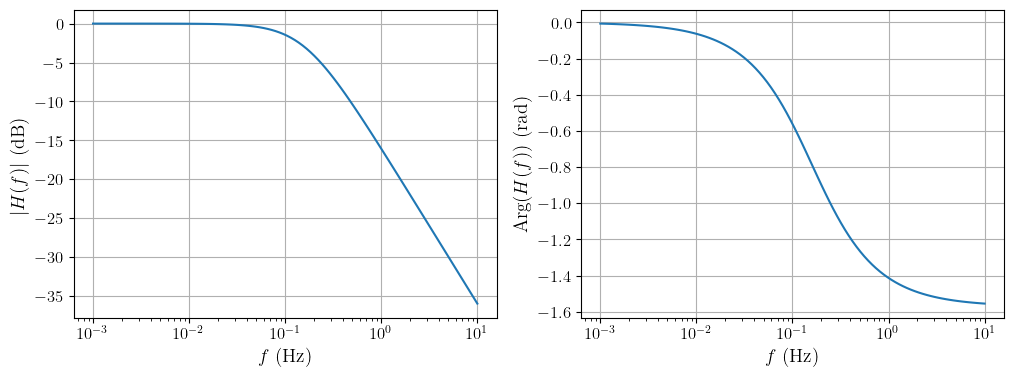

In [2]:
f = np.logspace(-3, 1, 100)
H = 1 / (1+1j*2*np.pi*f)

fig, axs = plt.subplots(1,2, figsize=(12,4))
axs[0].semilogx(f, 20*np.log10(abs(H)))
axs[0].set_xlabel("$f$ (Hz)")
axs[0].set_ylabel("$|H(f)|$ (dB)")
axs[1].semilogx(f, np.angle(H))
axs[1].set_xlabel("$f$ (Hz)")
axs[1].set_ylabel("Arg$(H(f))$ (rad)")
plt.savefig("td-rf-exp.svg")
plt.savefig("td-rf-exp.png")
plt.show()

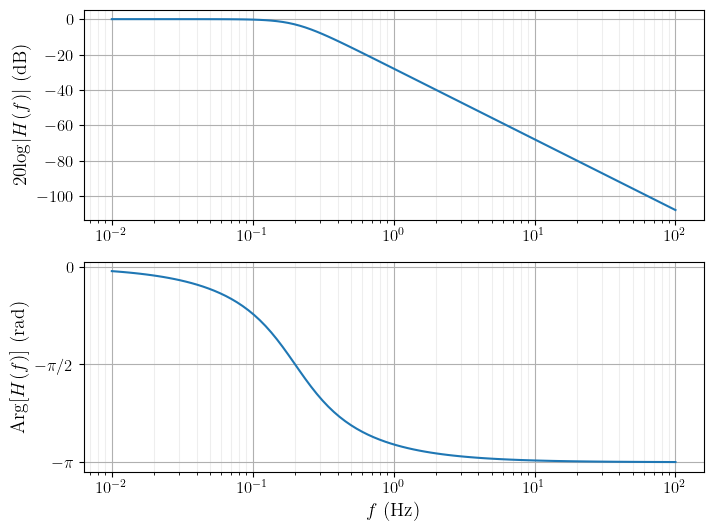

In [21]:
# Filtre analogique passe-bas
# Butterworth, fréquence de coupure = 0,2 Hz

# Réponse fréquentielle
fc = 0.2
f = np.logspace(-2, 2, 100)
b, a = si.butter(N=2, Wn=fc*2*np.pi, analog=True)
_, H = si.freqs(b, a, worN=f*2*np.pi)

# Préparation de la figure
yticks = np.arange(0,-4,-np.pi/2)
ylabels = ['$0$', '$-\\pi/2$', '$-\\pi$']

# Gain
fig, axs = plt.subplots(2, 1, figsize=(8,6))
axs[0].semilogx(f, 20*np.log10(abs(H)))
axs[0].set_ylabel("$20\\mathrm{log}|H(f)|$ (dB)")
axs[0].grid(visible=True, which='minor', color='#eee')

# Phase
axs[1].semilogx(f, np.angle(H))
axs[1].set_xlabel("$f$ (Hz)")
axs[1].set_ylabel("$\\mathrm{Arg}[H(f)]$ (rad)")
axs[1].set_yticks(yticks, ylabels)
axs[1].grid(visible=True, which='minor', color='#eee')

# Enregistrement et affichage
plt.savefig("fana-filtre1.svg")
plt.savefig("fana-filtre1.png")
plt.show()

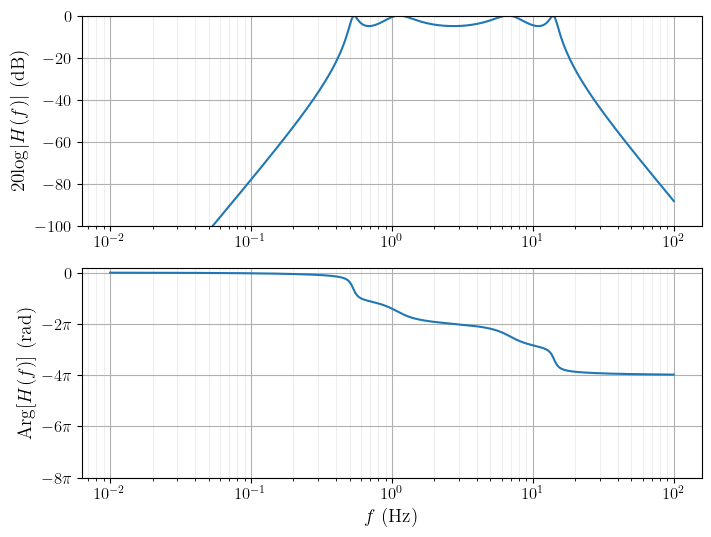

In [ ]:
# Filtre analogique passe-bande
# Tchebychev I, fréquences de coupure = 0,5 et 15 Hz

# Réponse fréquentielle
fc = np.array([.5, 15.])
Rp = 5
f = np.logspace(-2, 2, 300)
b, a = si.cheby1(N=7, rp=Rp, Wn=fc*2*np.pi, btype='bandpass', analog=True)
_, H = si.freqs(b, a, worN=f*2*np.pi)

# Préparation de la figure
yticks = np.arange(0,-30,-2*np.pi)
ylabels = ['$0$', '$-2\\pi$', '$-4\\pi$', '$-6\\pi$', '$-8\\pi$']

# Gain
fig, axs = plt.subplots(2, 1, figsize=(8,6))
axs[0].semilogx(f, 20*np.log10(abs(H)))
axs[0].set_ylabel("$20\\mathrm{log}|H(f)|$ (dB)")
axs[0].grid(visible=True, which='minor', color='#eee')
axs[0].set_ylim([-100,0])

# Phase
axs[1].semilogx(f, np.unwrap(np.angle(H)))
axs[1].set_xlabel("$f$ (Hz)")
axs[1].set_ylabel("$\\mathrm{Arg}[H(f)]$ (rad)")
axs[1].set_yticks(yticks, ylabels)
axs[1].grid(visible=True, which='minor', color='#eee')

# Enregistrement et affichage
plt.savefig("fana-filtre2.svg")
plt.savefig("fana-filtre2.png")
plt.show()